# Training GCN model

## Import Lib and define paths

In [1]:
# === Path Variables ===# Healthy

import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import seaborn as sns  # For enhanced visualizations of heatmaps
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics

BASE_DIR = "../../../input_columns_1mm/input_columns"
QSM_DIR = "../../../QSM"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
THICKNESS_DIR = '../../../thickness_in_region'
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)
metadata_path = "../../../AD_DECODE_data3.xlsx"
df_metadata = pd.read_excel(metadata_path)


delete the abnormal QSM subjects

In [2]:
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]

In [3]:
# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#Load columns

# Base directory where subject folders (e.g., S00775_columns_1mm) are stored


In [4]:
# List of hemispheres
HEMIS = ["lh", "rh"]


In [5]:
# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]

region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]


## Read data

In [6]:
############################## METADATA ##############################

print("ADDECODE METADATA\n")

ADDECODE METADATA



In [7]:
# Zero-pad subject IDs to 5-digit strings
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

In [8]:
# Standardize MRI_Exam IDs
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)


In [9]:
# Drop fully empty rows and rows missing MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])


In [10]:
# === Filter metadata to match only included subject IDs ===
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()


In [11]:
# === Only keep valid IDs for reordering to avoid KeyError ===
valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]


In [12]:
# === Reorder safely ===
df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()


In [13]:
# === Clean 'Risk' column: treat NaNs and empty strings as 'NoRisk' ===
df_matched["Risk"] = (
    df_matched["Risk"]
    .fillna("NoRisk")                              # Replace NaNs
    .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
    .str.strip()                                   # Remove leading/trailing spaces
)


In [14]:
# === Filter only healthy or familial risk subjects ===
df_matched_filtered = df_matched[df_matched["Risk"].isin(["NoRisk", "Familial"])].copy()


In [15]:
# === Print summary ===
print("Remaining risk group distribution:")
print(df_matched_filtered["Risk"].value_counts())
print(f"\nSubjects before filtering: {len(df_matched)}")
print(f"Subjects after filtering:  {len(df_matched_filtered)}")


Remaining risk group distribution:
Risk
Familial    42
NoRisk      17
Name: count, dtype: int64

Subjects before filtering: 64
Subjects after filtering:  59


In [16]:
# Build age_dict from the healthy metadata dataframe
age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))


In [17]:
# === Extract filtered subject IDs (already cleaned and filtered to NoRisk / Familial) ===
subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [18]:
# === Initialize final dictionary: subject_id -> region -> matrix ===
column_data_md = {}
column_data_QSM = {}
column_data_thickness = {}


In [19]:
# === Loop through filtered subjects ===
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")  # Path to subject's folder
    subj_dict_thickness = {}
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder
    subj_dict_QSM = {}
    subj_dir_to_QSM = os.path.join(QSM_DIR, f"S{subj_id}", "QSM")  # Path to subject's QSM folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            QSM_filename = f"S{subj_id}_{region_key}_QSM.csv"
            # Construct full file path
            filepath = os.path.join(subj_dir, filename)
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)
            QSM_filepath = os.path.join(subj_dir_to_QSM, QSM_filename)

            if not os.path.exists(filepath):
                # print(f"[WARNING] Missing: {filepath}")
                continue
            if not os.path.exists(thickness_filepath):
                # print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            if not os.path.exists(QSM_filepath):
                # print(f"[WARNING] Missing QSM file: {QSM_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)
            subj_dict_thickness[region_key] = mean_thickness

            # Load MD CSV matrix as numpy array (float32)
            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            # Add mean thickness as an additional attribute to the matrix
            if mat.size == 0:
                print(f"[WARNING] Empty matrix for {filepath}")
                continue
            subj_dict[region_key] = mat

            # Load QSM CSV matrix as numpy array (float32)
            QSM_mat = pd.read_csv(QSM_filepath, header=None).values.astype(np.float32)
            if QSM_mat.size == 0:
                print(f"[WARNING] Empty QSM matrix for {QSM_filepath}")
                continue
            subj_dict_QSM[region_key] = QSM_mat



    if len(subj_dict) > 0:
        column_data_md[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_thickness) > 0:
        column_data_thickness[subj_id] = subj_dict_thickness
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")
    
    if len(subj_dict_QSM) > 0:
        column_data_QSM[subj_id] = subj_dict_QSM
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")


In [20]:
# === OPTIONAL: Print region shapes for each subject ===
# for subj_id, regions in column_data.items():
#     print(f"\nSubject {subj_id}:")
#     for region_name, matrix in regions.items():
#         print(f"  {region_name} → {matrix.shape}")


## Construct Graphs

In [21]:
# CONSTRUCT GRAPHS 

import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors


In [22]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index


In [23]:
# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, thickness_dict=None, k=10):
    """
    Builds a PyG Data object for a subject.
    If `thickness_dict` is provided, thickness will be attached as a global feature.
    """
    subj_regions = column_data[subj_id]
    x_np = np.vstack(list(subj_regions.values()))  # shape [N, F]
    x = torch.tensor(x_np, dtype=torch.float32)

    edge_index = build_knn_edge_index(x_np, k=k)
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id

    # Optional: add thickness as a global graph attribute
    if thickness_dict is not None and subj_id in thickness_dict:
        region_dict = thickness_dict[subj_id]  # dict: {region_key: value}
        
        # Use consistent ordering
        thickness_vec = [region_dict.get(key, 0.0) for key in region_keys]  # default to 0.0 for missing
        data.thickness = torch.tensor(thickness_vec, dtype=torch.float32)


    return data


In [24]:
# === STEP 3: Loop through all subjects and build their graphs ===

# Standard scale the matrices
def standard_scale(matrix):
    """
    Standard scale a single matrix: (matrix - mean) / std
    """
    mean = matrix.mean()
    std = matrix.std()
    if std != 0:
        matrix = (matrix - mean) / std
    return matrix

# Standard scale the matrices in dictionaries
def standard_scale_dict(data_dict):
    """
    Apply standard scaling to all matrices in a nested dictionary structure
    """
    for subj_id, region_data in data_dict.items():
        for region_key, matrix in region_data.items():
            data_dict[subj_id][region_key] = standard_scale(matrix)
    return data_dict

# Standard scale thickness values across all subjects
def standard_scale_thickness_dict(thickness_dict, save_stats=True, stats_filename="thickness_scaling_stats.csv"):
    """
    Apply standard scaling to thickness values across all subjects and regions
    
    Args:
        thickness_dict: Dictionary of thickness values
        save_stats: Whether to save global mean and std to CSV
        stats_filename: Filename for saving statistics
    
    Returns:
        scaled thickness_dict and tuple of (global_mean, global_std)
    """
    # First, collect all thickness values across all subjects and regions
    all_thickness_values = []
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            all_thickness_values.append(thickness_value)
    
    # Calculate global mean and std
    all_thickness_array = np.array(all_thickness_values)
    global_mean = np.mean(all_thickness_array)
    global_std = np.std(all_thickness_array)
    
    print(f"Thickness scaling statistics:")
    print(f"  Global mean: {global_mean:.6f}")
    print(f"  Global std:  {global_std:.6f}")
    print(f"  Total values: {len(all_thickness_values)}")
    
    # Save statistics to CSV if requested
    if save_stats:
        stats_df = pd.DataFrame({
            'statistic': ['mean', 'std', 'count'],
            'value': [global_mean, global_std, len(all_thickness_values)]
        })
        stats_df.to_csv(stats_filename, index=False)
        print(f"  Saved scaling statistics to: {stats_filename}")
    
    # Apply scaling to each subject's thickness values
    for subj_id, region_data in thickness_dict.items():
        for region_key, thickness_value in region_data.items():
            if global_std != 0:
                thickness_dict[subj_id][region_key] = (thickness_value - global_mean) / global_std
            else:
                thickness_dict[subj_id][region_key] = 0.0
    
    return thickness_dict, (global_mean, global_std)

print("Applying standard scaling to MD, QSM, and thickness data...")

# Apply standard scaling to all data
column_data_md = standard_scale_dict(column_data_md)
column_data_QSM = standard_scale_dict(column_data_QSM)
column_data_thickness, thickness_stats = standard_scale_thickness_dict(
    column_data_thickness, 
    save_stats=True, 
    stats_filename="thickness_scaling_stats.csv"
)

print("Standard scaling completed!")

# Build MD graphs for each subject
graph_data_list_md = []
graph_data_list_QSM = []

for subj_id in subject_ids:
    if subj_id not in age_dict:
        continue

    # Build MD graph with thickness attached
    if subj_id in column_data_md and subj_id in column_data_thickness:
        md_graph = build_graph_from_subject(subj_id, column_data_md, age_dict, thickness_dict=column_data_thickness)
        graph_data_list_md.append(md_graph)

    # Build QSM graph (no thickness)
    if subj_id in column_data_QSM:
        qsm_graph = build_graph_from_subject(subj_id, column_data_QSM, age_dict)
        graph_data_list_QSM.append(qsm_graph)

# Create lookup dictionary from subject IDs to their graphs
md_dict = {data.subject_id: data for data in graph_data_list_md}
qsm_dict = {data.subject_id: data for data in graph_data_list_QSM}

# Define region keys in a fixed order
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Build aligned list of MD, QSM graphs and thickness
aligned_graph_list = [
    (md_dict[sid], qsm_dict[sid], md_dict[sid].thickness)
    for sid in md_dict if sid in qsm_dict
]

Applying standard scaling to MD, QSM, and thickness data...
Thickness scaling statistics:
  Global mean: 2.870124
  Global std:  0.481487
  Total values: 4012
  Saved scaling statistics to: thickness_scaling_stats.csv
Standard scaling completed!


In [25]:
# === Example: How to load and use thickness scaling statistics in other scripts ===

def load_thickness_scaling_stats(stats_filename="thickness_scaling_stats.csv"):
    """
    Load thickness scaling statistics from CSV file
    
    Returns:
        tuple: (global_mean, global_std)
    """
    stats_df = pd.read_csv(stats_filename)
    stats_dict = dict(zip(stats_df['statistic'], stats_df['value']))
    
    global_mean = stats_dict['mean']
    global_std = stats_dict['std']
    
    print(f"Loaded thickness scaling statistics:")
    print(f"  Mean: {global_mean:.6f}")
    print(f"  Std:  {global_std:.6f}")
    
    return global_mean, global_std

def apply_thickness_scaling(thickness_value, global_mean, global_std):
    """
    Apply the same scaling used in training to new thickness values
    
    Args:
        thickness_value: Raw thickness value to scale
        global_mean: Global mean from training data
        global_std: Global std from training data
    
    Returns:
        Scaled thickness value
    """
    if global_std != 0:
        return (thickness_value - global_mean) / global_std
    else:
        return 0.0

# Example usage:
# mean, std = load_thickness_scaling_stats("thickness_scaling_stats.csv")
# scaled_thickness = apply_thickness_scaling(raw_thickness_value, mean, std)

In [26]:
def collate_fn_aligend(batch):
    md_data, qsm_data, _ = zip(*batch)  # we’ll re-fetch thickness below

    md_batch = Batch.from_data_list(md_data)
    qsm_batch = Batch.from_data_list(qsm_data)

    # Stack thickness from md_data (which now contains `.thickness`)
    thickness_tensor = torch.stack([d.thickness for d in md_data])

    return md_batch, qsm_batch, thickness_tensor

## Visualize graph_md ad graph_QSM


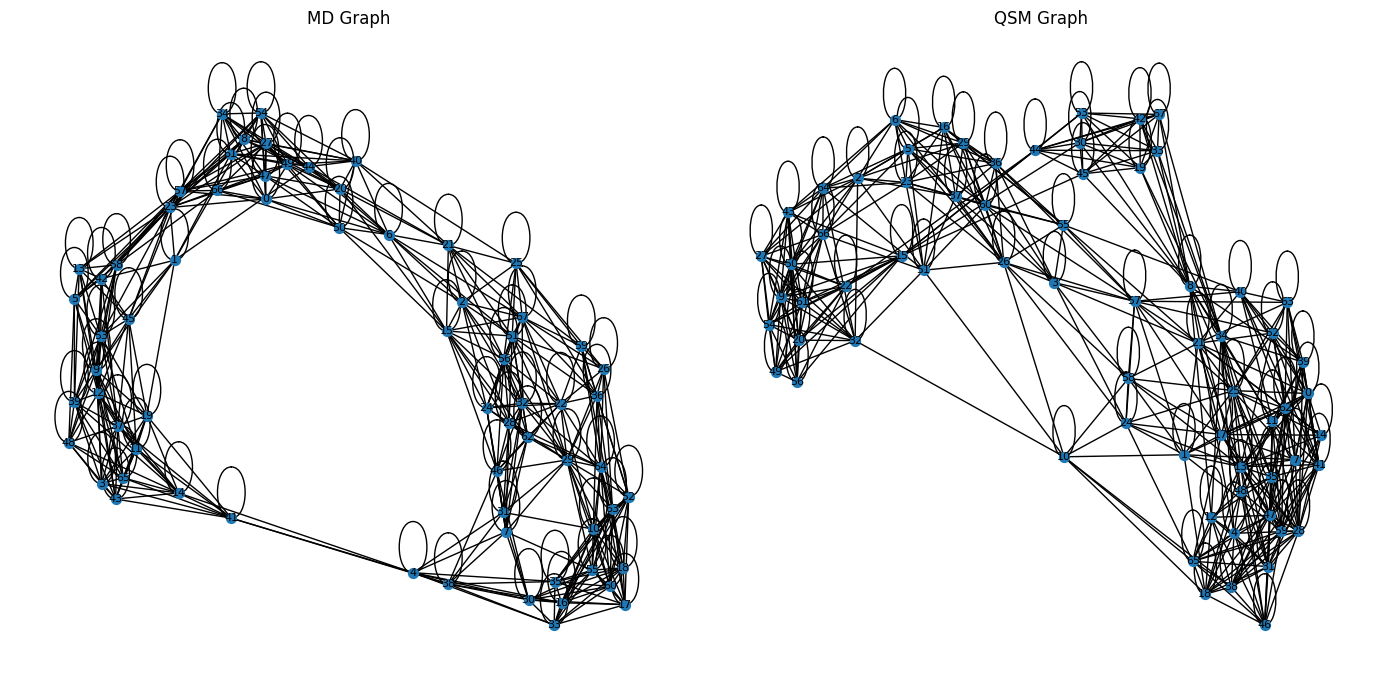

In [27]:

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


# === Pick the first subject's graph_md ===
graph_md = graph_data_list_md[0]

# === Convert PyG graph_md to NetworkX for visualization ===
G_md = to_networkx(graph_md, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos_md = nx.spring_layout(G_md, seed=42)  # force-directed layout

graph_QSM = graph_data_list_QSM[0]
G_QSM = to_networkx(graph_QSM, to_undirected=True)
pos_QSM = nx.spring_layout(G_QSM, seed=42)  # force-directed layout

# === Plot the MD and QSM graphs side by side ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
# === MD Graph ===
nx.draw(G_md, pos=pos_md, with_labels=True, node_size=50, font_size=8, ax=ax1)
ax1.set_title("MD Graph")
# === QSM Graph ===
nx.draw(G_QSM, pos=pos_QSM, with_labels=True, node_size=50, font_size=8, ax=ax2)
ax2.set_title("QSM Graph")
plt.tight_layout()
plt.show()


In [28]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define Model GCN

In [29]:
#DEFINE MODEL GCNs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(nn.Module):
    def __init__(self, input_dim=21, thickness_dim=68):  # ← match your thickness vector size
        super(BrainAgeGNN, self).__init__()

        # GCN layers for MD
        self.md_conv1 = GCNConv(input_dim, 64)
        self.md_bn1 = BatchNorm(64)
        self.md_conv2 = GCNConv(64, 128)
        self.md_bn2 = BatchNorm(128)
        self.md_conv3 = GCNConv(128, 128)
        self.md_bn3 = BatchNorm(128)

        # GCN layers for QSM
        self.qsm_conv1 = GCNConv(input_dim, 64)
        self.qsm_bn1 = BatchNorm(64)
        self.qsm_conv2 = GCNConv(64, 128)
        self.qsm_bn2 = BatchNorm(128)
        self.qsm_conv3 = GCNConv(128, 128)
        self.qsm_bn3 = BatchNorm(128)

        self.dropout = nn.Dropout(p=0.5)

        # Final MLP
        self.fc = nn.Sequential(
            nn.Linear(128 + 128 + thickness_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, data_md, data_qsm, data_thickness=None):
        # MD stream
        x_md = F.relu(self.md_bn1(self.md_conv1(data_md.x, data_md.edge_index)))
        x_md = F.relu(self.md_bn2(self.md_conv2(x_md, data_md.edge_index)))
        x_md_res = x_md
        x_md = F.relu(self.md_bn3(self.md_conv3(x_md, data_md.edge_index)))
        x_md = x_md + x_md_res
        x_md = global_mean_pool(x_md, data_md.batch)
        x_md = self.dropout(x_md)

        # QSM stream
        x_qsm = F.relu(self.qsm_bn1(self.qsm_conv1(data_qsm.x, data_qsm.edge_index)))
        x_qsm = F.relu(self.qsm_bn2(self.qsm_conv2(x_qsm, data_qsm.edge_index)))
        x_qsm_res = x_qsm
        x_qsm = F.relu(self.qsm_bn3(self.qsm_conv3(x_qsm, data_qsm.edge_index)))
        x_qsm = x_qsm + x_qsm_res
        x_qsm = global_mean_pool(x_qsm, data_qsm.batch)
        x_qsm = self.dropout(x_qsm)

        # Combine MD, QSM, and thickness
        if data_thickness is not None:
            thickness = data_thickness  # already [B, R]
            x = torch.cat([x_md, x_qsm, thickness], dim=1)
        else:
            x = torch.cat([x_md, x_qsm], dim=1)

        return self.fc(x)


In [30]:
  #train and eval funcions  
    
from torch.optim import Adam
from torch_geometric.loader import DataLoader  # Usamos el DataLoader de torch_geometric

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data_md, data_QSM, data_thickness in train_loader:
        data_md = data_md.to(device)  # GPU
        data_QSM = data_QSM.to(device)
        data_thickness = data_thickness.to(device) if data_thickness is not None else None
        optimizer.zero_grad()
        output = model(data_md, data_QSM, data_thickness).view(-1)
        loss = criterion(output, data_md.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data_md, data_QSM, data_thickness in test_loader:
            data_md = data_md.to(device)
            data_QSM = data_QSM.to(device)
            data_thickness = data_thickness.to(device) if data_thickness is not None else None
            output = model(data_md, data_QSM, data_thickness).view(-1)
            loss = criterion(output, data_md.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)


## Training

In [31]:
#Training

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Training settings
epochs = 300
patience = 40
k = 7  # Number of folds
batch_size = 6

# === Initialize loss and tracking ===
all_train_losses = []
all_test_losses = []
all_early_stopping_epochs = []

# === Extract subject IDs from graph list ===
graph_subject_ids = [data.subject_id for data in graph_data_list_md]

# === Get matching ages in the same order ===
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])

# === Create age bins for stratification ===
age_bins = pd.qcut(ages, q=5, labels=False)  # 5 quantiles


In [32]:
# Final check
print("Total subjects:", len(graph_data_list_md))
print("Total age bins:", len(age_bins))

from sklearn.model_selection import StratifiedKFold
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import torch
import numpy as np
from torch_geometric.loader import DataLoader



Total subjects: 59
Total age bins: 59


In [33]:
# Stratified split by age bins
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
repeats_per_fold = 10


In [34]:
# === Build age vector and age bins ===
graph_subject_ids = [data.subject_id for data in graph_data_list_md]
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])
age_bins = pd.qcut(ages, q=5, labels=False)


### Record set split

In [ ]:
# If split exists, skip
if os.path.exists("../set_split/train_indices_fold_0.csv"):
    print("Split files already exist. Skipping train/test split.")
else:
    # Split the training set and record in '../set_split/'
    train_indices_all = np.empty((k,), dtype=object)
    test_indices_all = np.empty((k,), dtype=object)

    # Store the indices for each fold
    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(ages)), age_bins)):
        print(f"Fold {fold+1}: Train indices - {train_idx}, Test indices - {test_idx}")
        train_indices_all[fold] = train_idx
        test_indices_all[fold] = test_idx
        # Save to CSV
        np.savetxt(f"../set_split/train_indices_fold_{fold}.csv", train_idx, delimiter=",")
        np.savetxt(f"../set_split/test_indices_fold_{fold}.csv", test_idx, delimiter=",")


Fold 1: Train indices - [ 0  1  2  4  5  6  7  9 10 11 12 13 14 15 17 18 19 21 22 24 25 26 27 28
 29 31 32 33 36 37 38 39 40 41 42 44 45 46 47 48 49 50 51 52 53 54 55 56
 57 58], Test indices - [ 3  8 16 20 23 30 34 35 43]
Fold 2: Train indices - [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14 16 17 18 19 20 21 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37 38 39 41 42 43 44 46 47 49 50 51 53 54
 56 57], Test indices - [12 15 22 40 45 48 52 55 58]
Fold 3: Train indices - [ 0  1  2  3  4  5  6  7  8  9 11 12 13 15 16 17 20 21 22 23 24 25 26 27
 29 30 31 32 33 34 35 36 37 38 40 42 43 44 45 48 49 50 51 52 53 54 55 56
 57 58], Test indices - [10 14 18 19 28 39 41 46 47]
Fold 4: Train indices - [ 0  1  2  3  4  5  6  8  9 10 12 13 14 15 16 17 18 19 20 22 23 24 25 26
 27 28 29 30 31 33 34 35 36 37 39 40 41 42 43 45 46 47 48 49 50 51 52 53
 54 55 58], Test indices - [ 7 11 21 32 38 44 56 57]
Fold 5: Train indices - [ 0  1  3  5  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25 27 28
 29 30 31 3

In [ ]:
# Read the training and test indices from CSV files
for fold in range(k):
    train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    test_idx = np.loadtxt(f"../set_split/test_indices_fold_{fold}.csv", delimiter=",", dtype=int)

    train_data = [aligned_graph_list[i] for i in train_idx]
    test_data = [aligned_graph_list[i] for i in test_idx]

    fold_train_losses = []
    fold_test_losses = []

    for repeat in range(repeats_per_fold):
        print(f'  > Repeat {repeat+1}/{repeats_per_fold}')

        early_stop_epoch = None
        seed_everything(42 + repeat)

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_aligend)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)

        model = BrainAgeGNN(input_dim=21).to(device)

        optimizer = AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
        scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
        criterion = torch.nn.SmoothL1Loss(beta=1)

        best_loss = float('inf')
        patience_counter = 0

        train_losses = []
        test_losses = []

        for epoch in range(epochs):
            train_loss = train(model, train_loader, optimizer, criterion)
            test_loss = evaluate(model, test_loader, criterion)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if test_loss < best_loss:
                best_loss = test_loss
                patience_counter = 0
                torch.save(model.state_dict(), f"column_md_model_fold_{fold+1}_rep_{repeat+1}.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    early_stop_epoch = epoch + 1
                    print(f"    Early stopping triggered at epoch {early_stop_epoch}.")
                    break

            scheduler.step()

        if early_stop_epoch is None:
            early_stop_epoch = epochs

        all_early_stopping_epochs.append((fold + 1, repeat + 1, early_stop_epoch))

        fold_train_losses.append(train_losses)
        fold_test_losses.append(test_losses)

    all_train_losses.append(fold_train_losses)
    all_test_losses.append(fold_test_losses)


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\2581121043.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


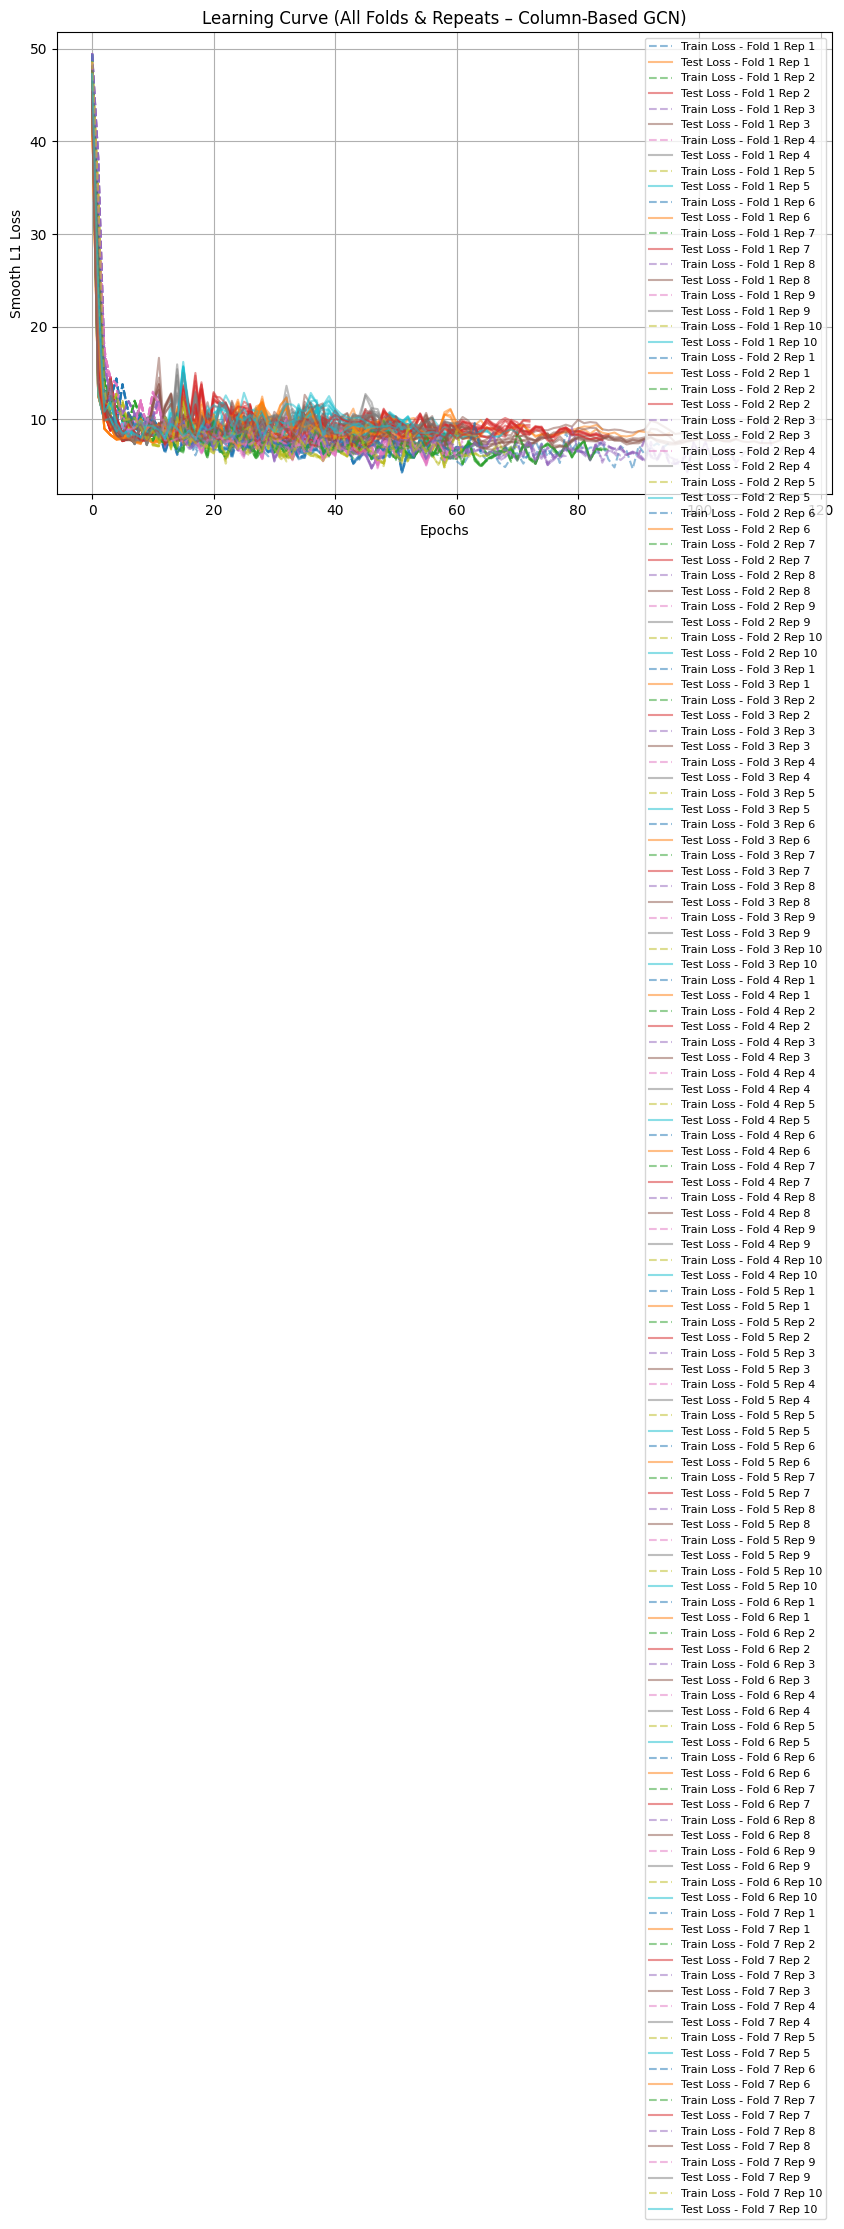

In [56]:
##################  LEARNING CURVE (ALL FOLDS + REPEATS)  ##################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot learning curves for each fold and repetition
for fold in range(k):
    for rep in range(repeats_per_fold):
        plt.plot(all_train_losses[fold][rep], label=f'Train Loss - Fold {fold+1} Rep {rep+1}', linestyle='dashed', alpha=0.5)
        plt.plot(all_test_losses[fold][rep], label=f'Test Loss - Fold {fold+1} Rep {rep+1}', alpha=0.5)

plt.xlabel("Epochs")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (All Folds & Repeats – Column-Based GCN)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [57]:
#######################  LEARNING CURVE (MEAN ± STD)  ########################
# Compute mean and std per epoch across all folds and repetitions
avg_train = []
avg_test = []

for epoch in range(epochs):
    epoch_train = []
    epoch_test = []
    for fold in range(k):
        for rep in range(repeats_per_fold):
            if epoch < len(all_train_losses[fold][rep]):
                epoch_train.append(all_train_losses[fold][rep][epoch])
                epoch_test.append(all_test_losses[fold][rep][epoch])
    avg_train.append((np.mean(epoch_train), np.std(epoch_train)))
    avg_test.append((np.mean(epoch_test), np.std(epoch_test)))



In [58]:
# Unpack values
train_mean, train_std = zip(*avg_train)
test_mean, test_std = zip(*avg_test)

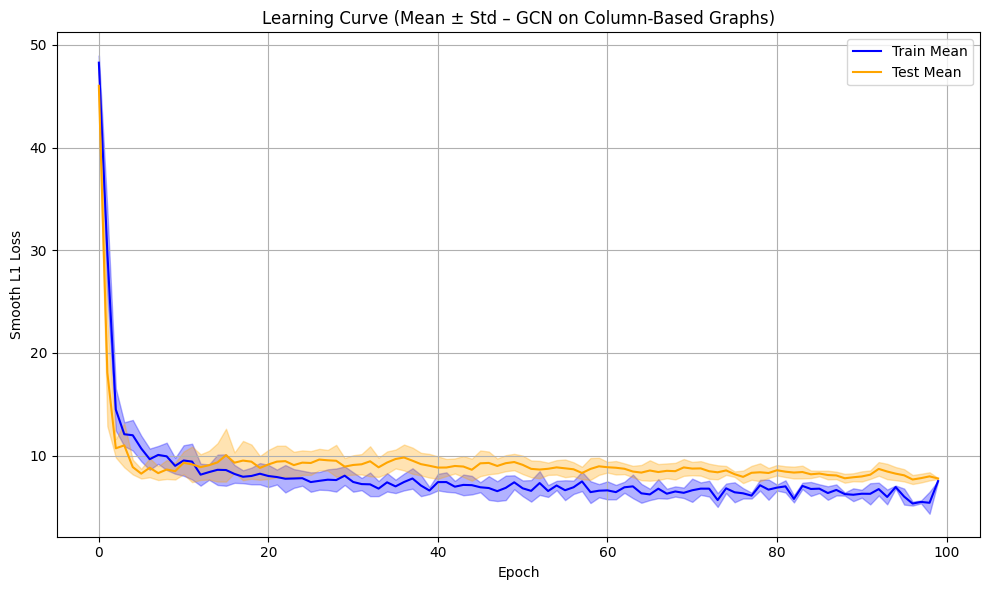

In [59]:
# Plot mean ± std
plt.figure(figsize=(10, 6))

plt.plot(train_mean, label="Train Mean", color="blue")
plt.fill_between(range(epochs), np.array(train_mean) - np.array(train_std),
                 np.array(train_mean) + np.array(train_std), color="blue", alpha=0.3)

plt.plot(test_mean, label="Test Mean", color="orange")
plt.fill_between(range(epochs), np.array(test_mean) - np.array(test_std),
                 np.array(test_mean) + np.array(test_std), color="orange", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (Mean ± Std – GCN on Column-Based Graphs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)

In [60]:
##################  PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)  ##################

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Ignore future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# === Initialize storage ===
fold_mae_list = []
fold_r2_list = []
fold_rmse_list = []

all_subject_ids = []
all_y_true = []
all_y_pred = []

# Create a new folder to save the y_true, y_pred, and subject_ids in each fold and repeat
if not os.path.exists("column_md_results"):
    os.makedirs("column_md_results")

for fold in range(k):
    train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
    test_idx = np.loadtxt(f"../set_split/test_indices_fold_{fold}.csv", delimiter=",", dtype=int)

    print(f'\n--- Evaluating Fold {fold+1}/{k} ---')

    test_data = [aligned_graph_list[i] for i in test_idx]
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)
    train_data = [aligned_graph_list[i] for i in train_idx]
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_aligend)

    repeat_maes = []
    repeat_r2s = []
    repeat_rmses = []

    for rep in range(repeats_per_fold):
        print(f"  > Repeat {rep+1}/{repeats_per_fold}")

        model = BrainAgeGNN(input_dim=21).to(device)  # ← Your model

        model.load_state_dict(torch.load(f"column_md_model_fold_{fold+1}_rep_{rep+1}.pt"))  # Load saved model
        model.eval()

        subject_id_repeat = []
        y_true_repeat = []
        y_pred_repeat = []

        subject_id_repeat_train = []
        y_true_repeat_train = []
        y_pred_repeat_train = []

        with torch.no_grad():
            for data_md, data_qsm, data_thickness in test_loader:
                data_md = data_md.to(device)
                data_qsm = data_qsm.to(device)
                data_thickness = data_thickness.to(device)
                output = model(data_md, data_qsm, data_thickness).view(-1)
                subject_id_repeat.extend(data_md.subject_id)
                y_pred_repeat.extend(output.cpu().tolist())
                y_true_repeat.extend(data_md.y.cpu().tolist())
            # Save predictions and true values to files
            test_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat,
                'y_true': y_true_repeat,
                'y_pred': y_pred_repeat
            })
            test_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_test_results.csv", index=False)

            for data_md, data_qsm, data_thickness in train_loader:
                data_md = data_md.to(device)
                data_qsm = data_qsm.to(device)
                data_thickness = data_thickness.to(device)
                output = model(data_md, data_qsm, data_thickness).view(-1)
                subject_id_repeat_train.extend(data_md.subject_id)
                y_pred_repeat_train.extend(output.cpu().tolist())
                y_true_repeat_train.extend(data_md.y.cpu().tolist())
            # Save predictions and true values for training data
            train_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat_train,
                'y_true': y_true_repeat_train,
                'y_pred': y_pred_repeat_train
            })
            train_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_train_results.csv", index=False)

        # Compute metrics
        mae = mean_absolute_error(y_true_repeat, y_pred_repeat)
        r2 = r2_score(y_true_repeat, y_pred_repeat)
        rmse = np.sqrt(mean_squared_error(y_true_repeat, y_pred_repeat))

        repeat_maes.append(mae)
        repeat_r2s.append(r2)
        repeat_rmses.append(rmse)

        all_y_true.extend(y_true_repeat)
        all_y_pred.extend(y_pred_repeat)
        all_subject_ids.extend(subject_id_repeat)

    fold_mae_list.append(repeat_maes)
    fold_r2_list.append(repeat_r2s)
    fold_rmse_list.append(repeat_rmses)

    print(f">> Fold {fold+1} | MAE: {np.mean(repeat_maes):.2f} ± {np.std(repeat_maes):.2f} | "
          f"R²: {np.mean(repeat_r2s):.2f} ± {np.std(repeat_r2s):.2f} | "
          f"RMSE: {np.mean(repeat_rmses):.2f} ± {np.std(repeat_rmses):.2f}")



C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:24: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.l


--- Evaluating Fold 1/7 ---
  > Repeat 1/10
  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 1 | MAE: 6.62 ± 0.58 | R²: 0.58 ± 0.05 | RMSE: 8.18 ± 0.45

--- Evaluating Fold 2/7 ---
  > Repeat 1/10


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:24: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.l

  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 2 | MAE: 6.73 ± 0.39 | R²: 0.68 ± 0.03 | RMSE: 8.85 ± 0.39

--- Evaluating Fold 3/7 ---
  > Repeat 1/10


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:24: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.l

...

  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 5 | MAE: 9.40 ± 0.90 | R²: 0.19 ± 0.17 | RMSE: 11.67 ± 1.20

--- Evaluating Fold 6/7 ---
  > Repeat 1/10


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:24: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.l

  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 6 | MAE: 5.98 ± 0.78 | R²: 0.80 ± 0.05 | RMSE: 7.27 ± 0.88

--- Evaluating Fold 7/7 ---
  > Repeat 1/10


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:24: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_idx = np.loadtxt(f"../set_split/train_indices_fold_{fold}.csv", delimiter=",", dtype=int)
C:\Users\22679\AppData\Local\Temp\ipykernel_18592\4165965093.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.l

  > Repeat 2/10
  > Repeat 3/10
  > Repeat 4/10
  > Repeat 5/10
  > Repeat 6/10
  > Repeat 7/10
  > Repeat 8/10
  > Repeat 9/10
  > Repeat 10/10
>> Fold 7 | MAE: 7.25 ± 0.89 | R²: 0.67 ± 0.10 | RMSE: 9.04 ± 1.31


In [61]:
# === Final aggregate results ===
all_maes = np.array(fold_mae_list).flatten()
all_r2s = np.array(fold_r2_list).flatten()
all_rmses = np.array(fold_rmse_list).flatten()

print("\n================== FINAL METRICS (COLUMN-BASED GCN) ==================")
print(f"Global MAE:  {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}")
print(f"Global R²:   {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}")
print(f"Global RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")
print("=======================================================================")



================== FINAL METRICS (COLUMN-BASED GCN) ==================
Global MAE:  6.76 ± 1.74
Global R²:   0.58 ± 0.25
Global RMSE: 8.50 ± 2.18


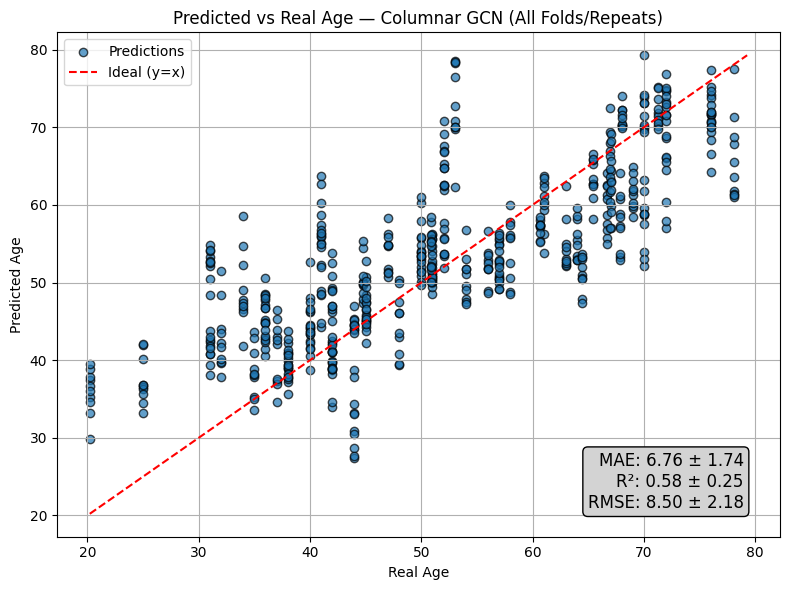

In [62]:
######################  PLOT TRUE VS PREDICTED AGES (COLUMN-BASED)  ######################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot of true vs predicted ages
plt.scatter(all_y_true, all_y_pred, alpha=0.7, edgecolors='k', label="Predictions")


# Diagonal (ideal prediction)
min_val = min(min(all_y_true), min(all_y_pred))
max_val = max(max(all_y_true), max(all_y_pred))
margin = (max_val - min_val) * 0.05
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)


# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age — Columnar GCN (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()



In [63]:
# Save all_y_true and all_y_pred to CSV
import pandas as pd
# Create a DataFrame from the true and predicted values
# For each subject, there're 7 folds and 10 repeats, so we can flatten the lists and match them
# all_y_true = 67 subjects * 10 repeats * 7 folds = 4690 values
# all_y_pred = 67 subjects * 10 repeats * 7 folds = 4690 values
# Flatten subject IDs if they are lists of lists
def flatten(l):
    return [item for sublist in l for item in sublist] if isinstance(l[0], list) else l

flat_subject_ids = flatten(all_subject_ids)

# Print the length of flat_subject_ids
print(f"Total subjects in flattened list: {len(flat_subject_ids)}")

Total subjects in flattened list: 590


In [64]:
df_results = pd.DataFrame({
    'subject_id': flat_subject_ids,
    'y_true': all_y_true,
    'y_pred': all_y_pred
})
# Save the mean and std of the predicted ages for each subject
df_results_mean_std = df_results.groupby('subject_id').agg(
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    y_pred_mean=('y_pred', 'mean'),
    y_pred_std=('y_pred', 'std')
).reset_index()
# Save to CSV
df_results_mean_std.to_csv("column_based_gcn_results.csv", index=False)

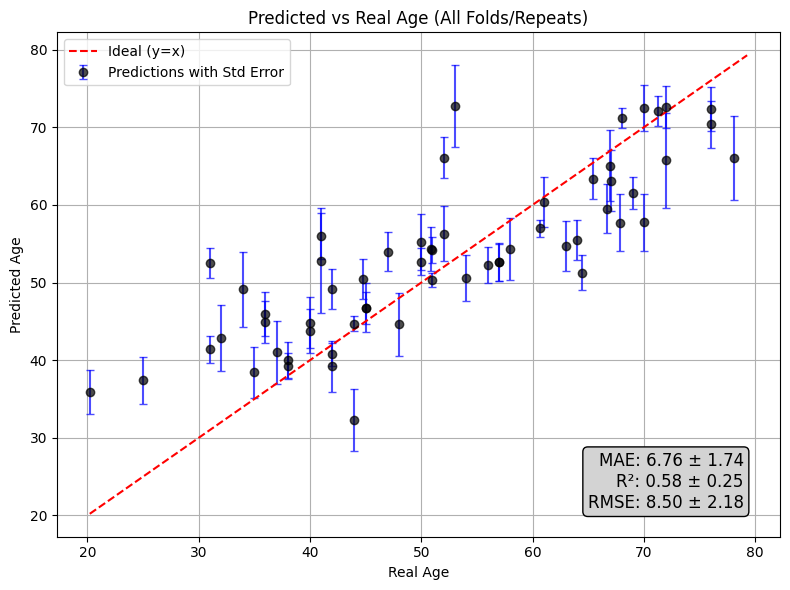

In [65]:
# Plot y_true vs y_pred with error bar being the std of y_pred for each subject
plt.figure(figsize=(8, 6))
plt.errorbar(df_results_mean_std['y_true_mean'], df_results_mean_std['y_pred_mean'],
             yerr=df_results_mean_std['y_pred_std'], fmt='o', alpha=0.7,
             label='Predictions with Std Error', color='black', ecolor='blue',
                capsize=3)
# Diagonal (ideal prediction)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
#Evaluation done


## Final Model training on healthy+Familial

In [67]:
############################################

# FINAL MODEL TRAINING ON HEALTHY + FAMILIAL

############################################

print("\n=== Training Final Model on All Healthy + Familial Subjects ===")

from torch_geometric.loader import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

# === Create DataLoader for all healthy + familial subjects ===
final_train_loader = DataLoader(aligned_graph_list, batch_size=6, shuffle=True, collate_fn=collate_fn_aligend)

# === Initialize model ===
final_model = BrainAgeGNN(input_dim=21).to(device)

# === Optimizer and scheduler ===
optimizer = AdamW(final_model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# === Loss function ===
criterion = torch.nn.SmoothL1Loss(beta=1)

# === Train the model ===
epochs = 100
for epoch in range(epochs):
    final_model.train()
    total_loss = 0

    for data_md, data_qsm, data_thickness in final_train_loader:
        data_md = data_md.to(device)
        data_qsm = data_qsm.to(device)
        data_thickness = data_thickness.to(device)

        optimizer.zero_grad()
        output = final_model(data_md, data_qsm, data_thickness).view(-1)
        loss = criterion(output, data_md.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(final_train_loader)
    print(f"Epoch {epoch + 1:03d} | Loss: {avg_loss:.4f}")
    scheduler.step()

# === Save the trained model AFTER training ===
torch.save(final_model.state_dict(), "E:\\test\\column_md_model_trained_on_all_healthy.pt")
print("Final trained model saved successfully.")



=== Training Final Model on All Healthy + Familial Subjects ===
Epoch 001 | Loss: 48.3735
Epoch 002 | Loss: 24.4445
Epoch 003 | Loss: 13.9401
Epoch 004 | Loss: 11.2192
Epoch 005 | Loss: 9.8980
Epoch 006 | Loss: 10.8967
Epoch 007 | Loss: 9.6747
Epoch 008 | Loss: 8.9269
Epoch 009 | Loss: 7.5871
Epoch 010 | Loss: 9.4693
Epoch 011 | Loss: 8.4368
Epoch 012 | Loss: 7.2655
Epoch 013 | Loss: 9.9142
Epoch 014 | Loss: 8.3162
Epoch 015 | Loss: 8.4549
Epoch 016 | Loss: 9.1601
Epoch 017 | Loss: 11.5810
Epoch 018 | Loss: 9.0647
Epoch 019 | Loss: 9.0303
Epoch 020 | Loss: 10.5776
Epoch 021 | Loss: 7.4464
Epoch 022 | Loss: 8.8366
Epoch 023 | Loss: 7.2672
Epoch 024 | Loss: 6.4915
Epoch 025 | Loss: 6.9388
Epoch 026 | Loss: 7.6533
Epoch 027 | Loss: 6.3135
Epoch 028 | Loss: 6.6658
Epoch 029 | Loss: 7.1568
Epoch 030 | Loss: 6.6418
Epoch 031 | Loss: 7.4433
Epoch 032 | Loss: 7.2223
Epoch 033 | Loss: 7.7826
Epoch 034 | Loss: 7.9156
Epoch 035 | Loss: 7.4747
Epoch 036 | Loss: 6.2508
Epoch 037 | Loss: 8.0025
Epo

In [68]:
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
import torch

# === Load the trained model on all healthy+familial subjects ===
model = BrainAgeGNN(input_dim=21, thickness_dim=68).to(device)
import os
#state = torch.load("E:\\test\\column_md_model_trained_on_all_healthy.pt")
#print(model.load_state_dict(state, strict=True))  # check for missing/unexpected keys
model = final_model.eval()

# === Prepare storage for results ===
all_preds = []        # Predicted ages
all_ids = []          # Subject IDs
all_true_ages = []    # Ground-truth chronological ages

all_graph_loader = DataLoader(aligned_graph_list, batch_size=1, shuffle=False, collate_fn=collate_fn_aligend)


# === Perform inference ===
with torch.no_grad():  # Disable gradient computation for efficiency
    for data_md, data_qsm, data_thickness in all_graph_loader:
        #print(data_md.x.shape, data_md.batch.shape)  # sanity check
        data_md = data_md.to(device)  # Move data to GPU or CPU
        data_qsm = data_qsm.to(device)
        data_thickness = data_thickness.to(device)  # Move thickness to device
        output = model(data_md, data_qsm, data_thickness).view(-1)  # Predict age for each graph in the batch
        all_preds.extend(output.cpu().tolist())        # Store predictions
        all_true_ages.extend(data_md.y.cpu().tolist())    # Store true ages
        all_ids.extend(data_md.subject_id)                # Store subject IDs
        #print("Thickness shape:", data_thickness.shape)  # should be [batch_size, 68]
        #print("Sample thickness[0]:", data_thickness[0][:5])


# === Organize results into a DataFrame ===
df_results = pd.DataFrame({
    "subject_id": all_ids,
    "age": all_true_ages,
    "predicted_age": all_preds
})

df_results["BAG"] = df_results["predicted_age"] - df_results["age"]

# === Save results to CSV file ===
print("Pred mean:", np.mean(all_preds))
print("Pred std:", np.std(all_preds))
# Sanity check: inspect structure of first batch

Pred mean: 51.73438346992105
Pred std: 13.19030699330178


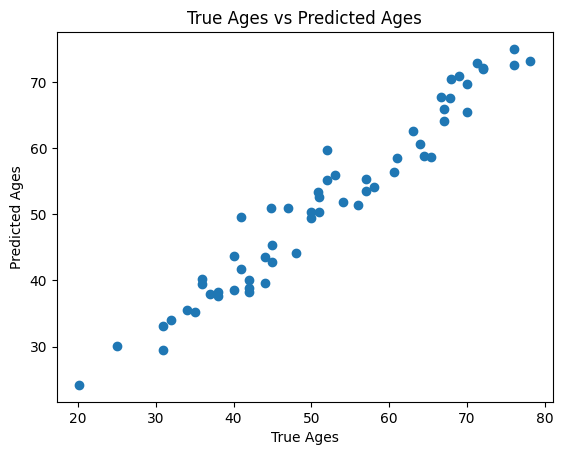

In [69]:
# Plot the preds vs true ages
import matplotlib.pyplot as plt

plt.scatter(all_true_ages, all_preds)
plt.xlabel('True Ages')
plt.ylabel('Predicted Ages')
plt.title('True Ages vs Predicted Ages')
plt.show()

In [70]:
# === Notes ===

# We selected 100 epochs for the final model training based on the early stopping

# behavior observed during cross-validation. Most runs converged between 60–90 epochs (mean=86)

# so 100 allows for full convergence without early stopping.

